In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [2]:
# Lire le CSV
df = pd.read_csv("data/df_num_cleaned.csv")
df=df.dropna()

In [3]:
pd.set_option("display.max_columns", None)
df.head()
#len(df)
#df.isna().sum()

,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,Grazing_Footprint_Production,Forest_Footprint_Production,Fish_Footprint_Production,BuiltUp_Footprint_Production,Carbon_Footprint_Production,Total_Footprint_Production,Cropland_Footprint_Consumption,Grazing_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,BuiltUp_Footprint_Consumption,Carbon_Footprint_Consumption,Total_Footprint_Consumption,Cropland,Grazing land,Forest land,Fishing ground,BuiltUp_Biocapacity,Total_Biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required,Overshoot_Day_DOY,Income Group_LM,Income Group_UM,Income Group_HI,Quality Score_2B,Quality Score_2C,Quality Score_3A,Region_Asia-Pacific,Region_Central America/Caribbean,Region_EU,Region_Middle East/Central Asia,Region_North America,Region_Other Europe,Region_South America
1,71.0,78.4580,0.792,5046.032611,2.882740,0.362065,0.195718,0.163174,0.018087,0.042248,0.639822,1.421114,0.547458,0.195848,0.207561,0.040595,0.042248,0.852748,1.886458,0.362065,0.195718,0.310590,0.082072,0.042248,0.992693,-0.893765,1.191981,1.900343,305.0,0,1,0,0,0,1,0,0,0,0,0,1,0
2,70.9,76.6930,0.746,4759.830054,42.228398,0.249653,0.108329,0.079857,0.008417,0.037283,1.200642,1.684182,0.642917,0.150201,0.163528,0.013793,0.037283,1.333187,2.340909,0.249653,0.249356,0.025333,0.007541,0.037283,0.569166,-1.771742,1.479132,4.112872,245.0,0,1,0,0,0,1,0,0,0,0,0,0,0
5,72.8,76.5200,0.842,10076.395406,44.361102,2.207423,0.969692,0.250688,0.174034,0.092705,1.381537,5.076080,0.908614,0.717147,0.276678,0.083593,0.092705,1.233009,3.311746,2.207423,1.721421,0.609912,1.548194,0.092705,6.179656,2.867910,2.092567,0.535911,173.0,0,1,0,0,0,1,0,0,0,0,0,0,1
6,71.8,74.9450,0.771,4406.741763,2.951750,0.208557,0.156552,0.198053,0.000044,0.035763,0.652324,1.251293,0.482839,0.201365,0.267196,0.000756,0.035763,0.912473,1.900392,0.208557,0.263465,0.092649,0.015682,0.035763,0.616116,-1.284276,1.200786,3.084469,302.0,1,0,0,0,0,1,0,0,0,1,0,0,0
7,75.6,82.7488,0.943,57032.237052,24.898199,1.921158,2.413255,0.984093,0.041369,0.040870,5.445939,10.846684,0.765995,0.522429,0.947139,0.112822,0.040870,4.696784,7.086039,1.921158,4.613393,1.959529,2.936743,0.040870,11.471694,4.385655,4.477400,0.617698,80.0,0,0,1,0,0,1,1,0,0,0,0,0,0


In [6]:
features_tot = [
    'SDGi',
    'Life Expectancy',
    'HDI',
    'Per Capita GDP',
    'Population (millions)',

    'Cropland_Footprint_Production',
    'Grazing_Footprint_Production',
    'Forest_Footprint_Production',
    'Fish_Footprint_Production',
    'BuiltUp_Footprint_Production',
    'Carbon_Footprint_Production',

    'Cropland_Footprint_Consumption',
    'Grazing_Footprint_Consumption',
    'Forest_Footprint_Consumption',
    'Fish_Footprint_Consumption',
    'BuiltUp_Footprint_Consumption',
    'Carbon_Footprint_Consumption',

    'Cropland',
    'Grazing land',
    'Forest land',
    'Fishing ground',
    'BuiltUp_Biocapacity',

    'Ecological (Deficit) or Reserve',
    'Number of Earths required',
    'Number of Countries required',
    
    'Income Group_LM',
    'Income Group_UM',
    'Income Group_HI',

    'Quality Score_2B',
    'Quality Score_2C',
    'Quality Score_3A',

    'Region_Asia-Pacific',
    'Region_Central America/Caribbean',
    'Region_EU',
    'Region_Middle East/Central Asia',
    'Region_North America',
    'Region_Other Europe',
    'Region_South America'
]

In [7]:
'SDGi',
'Life Expectancy', 
'HDI', 
'Per Capita GDP', 
'Population (millions)', 
'Cropland_Footprint_Production', 
'BuiltUp_Footprint_Production', 
'Cropland_Footprint_Consumption', 
'Forest_Footprint_Consumption', 
'Fish_Footprint_Consumption', 
'Cropland', 
'Grazing land', 
'Ecological (Deficit) or Reserve', 
'Number of Earths required', 
'Income Group_HI', 
'Region_Other Europe'

16

16

In [8]:
features=[
    'SDGi',
    'Life Expectancy',
    'HDI', 
    'Per Capita GDP', 
    'Population (millions)', 
    'Cropland_Footprint_Production', 
    'BuiltUp_Footprint_Production', 
    'Cropland_Footprint_Consumption', 
    'Forest_Footprint_Consumption', 
    'Fish_Footprint_Consumption', 
    'Cropland', 
    'Grazing land', 
    'Ecological (Deficit) or Reserve', 
    'Number of Earths required', 
    'Income Group_HI', 
    'Region_Other Europe'
]

In [9]:
X=df[features]

In [10]:
print(X)

     SDGi  Life Expectancy    HDI  Per Capita GDP  Population (millions)  \
1    71.0          78.4580  0.792     5046.032611               2.882740   
2    70.9          76.6930  0.746     4759.830054              42.228398   
5    72.8          76.5200  0.842    10076.395406              44.361102   
6    71.8          74.9450  0.771     4406.741763               2.951750   
7    75.6          82.7488  0.943    57032.237052              24.898199   
..    ...              ...    ...             ...                    ...   
173  70.2          77.8140  0.889    41325.060182               9.630960   
174  80.0          81.2561  0.928    42894.354268              67.141703   
175  76.0          78.6390  0.925    54723.995402             327.096000   
177  69.8          71.5730  0.717     2408.610055              32.476199   
180  72.8          75.3170  0.700     1967.638624              95.546000   

     Cropland_Footprint_Production  BuiltUp_Footprint_Production  \
1                  

In [11]:
Y = df["Overshoot_Day_DOY"]

In [12]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=123
)

In [96]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

84
22
84
22


In [13]:
Y = df["Overshoot_Day_DOY"]

In [14]:
from sklearn.linear_model import LinearRegression

# Create model instance
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# Get model parameters
print(f"Slope (B1): {model.coef_[0]}")
print(f"Intercept (B0): {model.intercept_}")

# Predict values
y_pred = model.predict(X_test)
print("Predicted values:", y_pred)

print(len(y_pred))

Slope (B1): 3.0143552229986152
Intercept (B0): 523.9135917610823
Predicted values: [170.26765922 103.22258161 182.31537452 186.58786806 107.82027993
 110.98600916 161.70644702 103.90975257 217.5118416   20.55421428
 140.54666313   7.02540732 303.84526981 187.55907188 189.86912059
 231.2885802  104.26128565 143.78004369 287.09028377 261.16693417
 289.11516603 126.97646567]
22


In [15]:
# Évaluation
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2468.0617010571373


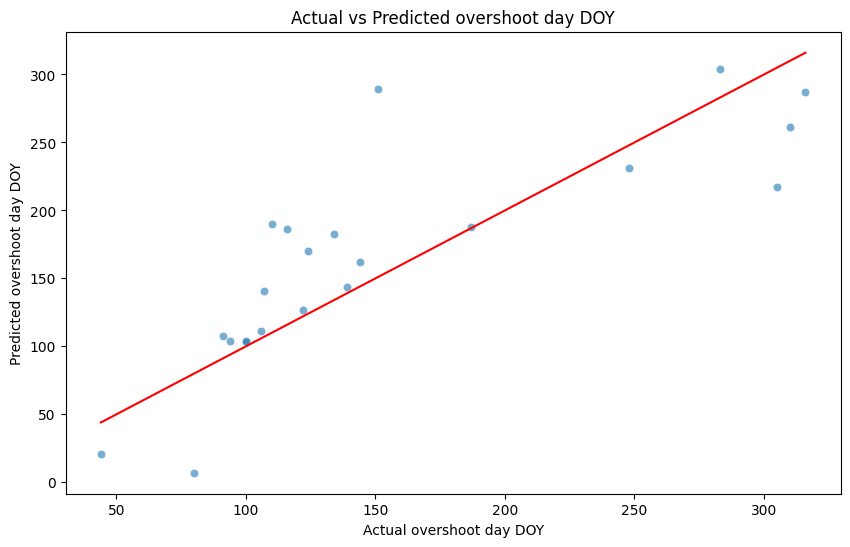

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY')
plt.show()

On a des valeurs négatives, ce qui est pas possible.

On va prédire avec le log(y_train) et log(y_test).

In [17]:
from sklearn.linear_model import LinearRegression

# Create model instance
model = LinearRegression()

log_y_train=np.log(y_train)

# Fit the model
model.fit(X_train, log_y_train)

# Get model parameters
print(f"Slope (B1): {model.coef_[0]}")
print(f"Intercept (B0): {model.intercept_}")

# Predict values
log_y_pred = model.predict(X_test)

y_pred2 = np.exp(log_y_pred)
print("Predicted values:", y_pred2)

print(len(y_pred2))

Slope (B1): 0.011033641594309888
Intercept (B0): 6.585958964609114
Predicted values: [145.40184125 102.10089381 159.4825467  152.1226803   98.27518151
 108.51754243 147.66327957  99.20310801 230.39643766  37.88807203
 125.50894432  63.67300694 302.33381875 184.3561229  146.48074026
 230.10379729 102.56480497 137.78264184 290.41499079 267.78869397
 239.39940218 123.12750095]
22


In [18]:
# Évaluation
mse = mean_squared_error(y_test, y_pred2)
print("MSE:", mse)

MSE: 955.4861743505239


La MSE est quand même bien meilleure.

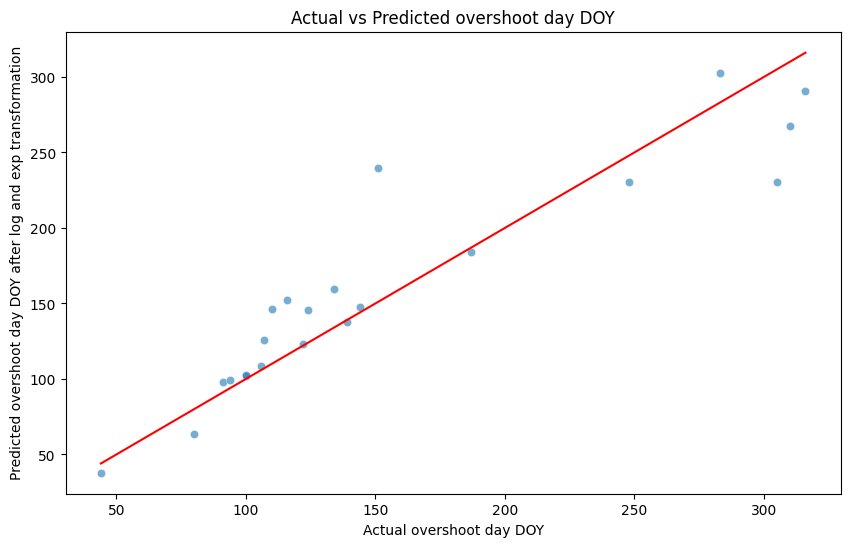

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred2, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY after log and exp transformation')
plt.show()

C'est mieux.

# Random Forest

Pour le random forest on peut mélanger des variables qualitatives et quantitatives mais il faut que ce soit des valeurs numériques.

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [37]:
df.head(2)

,SDGi,Life Expectancy,HDI,Per Capita GDP,Population (millions),Cropland_Footprint_Production,Grazing_Footprint_Production,Forest_Footprint_Production,Fish_Footprint_Production,BuiltUp_Footprint_Production,Carbon_Footprint_Production,Total_Footprint_Production,Cropland_Footprint_Consumption,Grazing_Footprint_Consumption,Forest_Footprint_Consumption,Fish_Footprint_Consumption,BuiltUp_Footprint_Consumption,Carbon_Footprint_Consumption,Total_Footprint_Consumption,Cropland,Grazing land,Forest land,Fishing ground,BuiltUp_Biocapacity,Total_Biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required,Overshoot_Day_DOY,Income Group_LM,Income Group_UM,Income Group_HI,Quality Score_2B,Quality Score_2C,Quality Score_3A,Region_Asia-Pacific,Region_Central America/Caribbean,Region_EU,Region_Middle East/Central Asia,Region_North America,Region_Other Europe,Region_South America
1,71.0,78.458,0.792,5046.032611,2.882740,0.362065,0.195718,0.163174,0.018087,0.042248,0.639822,1.421114,0.547458,0.195848,0.207561,0.040595,0.042248,0.852748,1.886458,0.362065,0.195718,0.310590,0.082072,0.042248,0.992693,-0.893765,1.191981,1.900343,305.0,0,1,0,0,0,1,0,0,0,0,0,1,0
2,70.9,76.693,0.746,4759.830054,42.228398,0.249653,0.108329,0.079857,0.008417,0.037283,1.200642,1.684182,0.642917,0.150201,0.163528,0.013793,0.037283,1.333187,2.340909,0.249653,0.249356,0.025333,0.007541,0.037283,0.569166,-1.771742,1.479132,4.112872,245.0,0,1,0,0,0,1,0,0,0,0,0,0,0


Test et train split (faut bien penser à déterminer les features, ici c'est fait plus haut)

In [38]:
X=df[features_tot]

In [39]:
Y = df["Overshoot_Day_DOY"]

In [40]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=123
)

In [41]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

84
22
84
22


In [42]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=123)

Hyper paramètres du random forest réalisé.

In [43]:
rf.get_params()
#on peut aussi aller sur le site de scikitlearn du randomforest pour voir les hyperparametre par défaut qui ont été utilisés vu qu'ici on a utilisé les paramètre par défaut.
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html 

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

In [44]:
y_pred_rf = rf.predict(X_test)

In [45]:
# Évaluation
mse = mean_squared_error(y_test, y_pred_rf)
print("MSE:", mse)

MSE: 28.244105272727268


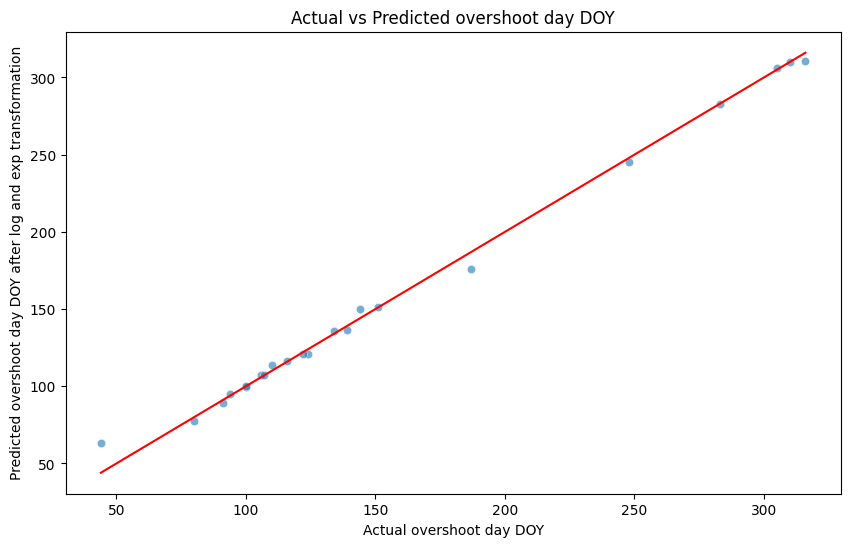

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted overshoot day DOY')
plt.xlabel('Actual overshoot day DOY')
plt.ylabel('Predicted overshoot day DOY after log and exp transformation')
plt.show()

#### Importance des variables par permutation

In [48]:
from sklearn.inspection import permutation_importance
import time

start_time = time.time()
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=122, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=features_tot)

Elapsed time to compute the importances: 8.020 seconds


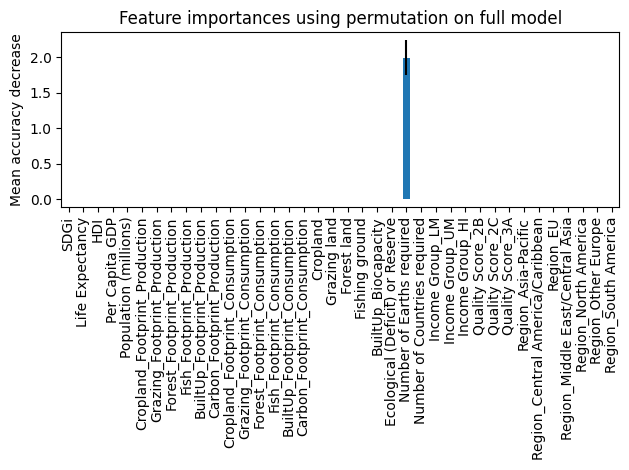

In [49]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()